In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df

,id_sentencia,año,tema_principal,tipo_accionante,sujeto_especial_proteccion,edad_aproximada,representacion,tipo_entidad,sector_entidad,derecho_salud,...,legitimacion_activa,legitimacion_pasiva,urgencia,afecta_minimo vital,afecta_salud,caso_involucra_servicio_publico,decision_corte,procedencia_tutela,dias_desde_hecho,hay_inmediatez
0,t-003,2022,seguridad_social,persona_natural,0,55.0,agente_oficioso,economia_mixta,salud,1,...,0,1,0,0,0,1,improcedente,0,7.0,1
1,t-256,2019,seguridad_social,persona_natural,1,69.0,directo,privada,otro,0,...,1,1,1,1,0,1,concede,1,74.0,1
2,t-056,2013,seguridad_social,persona_natural,0,NaN,apoderado,publica,otro,0,...,1,1,0,0,0,0,niega,1,NaN,0
3,t-852,2012,seguridad_social,persona_natural,1,65.0,apoderado,publica,otro,0,...,1,1,0,0,0,1,improcedente,0,NaN,0
4,t-608,2016,seguridad_social,persona_natural,1,50.0,apoderado,publica,pensiones,1,...,1,1,1,1,1,1,concede,1,30.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277,t-143,1996,igualdad,persona_natural,0,NaN,representante_legal,publica,administrativo,0,...,1,1,0,0,0,1,improcedente,0,210.0,1
278,t-569,2011,igualdad,persona_natural,0,NaN,directo,publica,otro,0,...,1,1,1,0,0,1,concede,1,27.0,1
279,t-140,2009,igualdad,persona_natural,1,1.0,representante_legal,privada,salud,1,...,1,1,0,0,1,1,niega,0,15.0,1
280,t-441,1997,igualdad,persona_natural,0,NaN,directo,publica,educacion,0,...,1,1,1,0,0,1,concede,1,NaN,1


In [4]:
f'El dataframe tiene {df.shape[0]} registros'

'El dataframe tiene 282 registros'

In [5]:
f'El dataframe tiene {df.shape[1]} variables'

'El dataframe tiene 29 variables'

In [6]:
df.dtypes

id_sentencia                           str
año                                  int64
tema_principal                         str
tipo_accionante                        str
sujeto_especial_proteccion           int64
edad_aproximada                    float64
representacion                         str
tipo_entidad                           str
sector_entidad                         str
derecho_salud                        int64
minimo_vital                         int64
debido_proceso                       int64
seguridad_social                     int64
igualdad                             int64
existe_otro_medio_defensa            int64
medio_es_idoneo                      int64
se_alega_perjuicio_irremediable      int64
perjuicio_irremediable_probado       int64
subsidiariedad_cumplida              int64
legitimacion_activa                  int64
legitimacion_pasiva                  int64
urgencia                             int64
afecta_minimo vital                  int64
afecta_salu

In [7]:
df_numericas = df.select_dtypes(include=['int64', 'float64'])

In [8]:
for i in df_numericas.columns:
    print(i)
    print(f'media: {df_numericas[i].mean()}, mediana: {df_numericas[i].median()}, moda: {df_numericas[i].mode()}')
    print()

año
media: 2014.3581560283687, mediana: 2016.0, moda: 0    2024
Name: año, dtype: int64

sujeto_especial_proteccion
media: 0.723404255319149, mediana: 1.0, moda: 0    1
Name: sujeto_especial_proteccion, dtype: int64

edad_aproximada
media: 46.908496732026144, mediana: 50.0, moda: 0    71.0
Name: edad_aproximada, dtype: float64

derecho_salud
media: 0.3829787234042553, mediana: 0.0, moda: 0    0
Name: derecho_salud, dtype: int64

minimo_vital
media: 0.2375886524822695, mediana: 0.0, moda: 0    0
Name: minimo_vital, dtype: int64

debido_proceso
media: 0.40425531914893614, mediana: 0.0, moda: 0    0
Name: debido_proceso, dtype: int64

seguridad_social
media: 0.35106382978723405, mediana: 0.0, moda: 0    0
Name: seguridad_social, dtype: int64

igualdad
media: 0.4148936170212766, mediana: 0.0, moda: 0    0
Name: igualdad, dtype: int64

existe_otro_medio_defensa
media: 0.8049645390070922, mediana: 1.0, moda: 0    1
Name: existe_otro_medio_defensa, dtype: int64

medio_es_idoneo
media: 0.26595

In [9]:
for i in df_numericas.columns:
    print(i)
    print(f'desviación estándar: {df[i].std()}')
    print(f'varianza: {df[i].var()}')
    print(f'rango: {df[i].max() - df[i].min()}')
    print(f'rango intercuartilico: {df[i].quantile(0.75) - df[i].quantile(0.25)}')
    print()

año
desviación estándar: 9.09006462460433
varianza: 82.62927487948308
rango: 34
rango intercuartilico: 15.0

sujeto_especial_proteccion
desviación estándar: 0.44811003635193974
varianza: 0.20080260467933675
rango: 1
rango intercuartilico: 1.0

edad_aproximada
desviación estándar: 24.033791856775157
varianza: 577.6231510147918
rango: 85.0
rango intercuartilico: 42.0

derecho_salud
desviación estándar: 0.48697737885575926
varianza: 0.2371469675172257
rango: 1
rango intercuartilico: 1.0

minimo_vital
desviación estándar: 0.4263624186552963
varianza: 0.18178491204159414
rango: 1
rango intercuartilico: 0.0

debido_proceso
desviación estándar: 0.4916197848662743
varianza: 0.2416900128719618
rango: 1
rango intercuartilico: 1.0

seguridad_social
desviación estándar: 0.4781513959794486
varianza: 0.2286287574770955
rango: 1
rango intercuartilico: 1.0

igualdad
desviación estándar: 0.4935795854244021
varianza: 0.2436208071477247
rango: 1
rango intercuartilico: 1.0

existe_otro_medio_defensa
desvi

In [10]:
for i in df_numericas:
    print(i)
    print(f'mínimo: {df[i].min()}')
    print(f'maximo: {df[i].max()}')
    print(f'cuartil 1: {df[i].quantile(0.25)}')
    print(f'cuartil 2: {df[i].quantile(0.50)}')
    print(f'cuartil 3: {df[i].quantile(0.75)}')
    print()

año
mínimo: 1992
maximo: 2026
cuartil 1: 2008.0
cuartil 2: 2016.0
cuartil 3: 2023.0

sujeto_especial_proteccion
mínimo: 0
maximo: 1
cuartil 1: 0.0
cuartil 2: 1.0
cuartil 3: 1.0

edad_aproximada
mínimo: 1.0
maximo: 86.0
cuartil 1: 26.0
cuartil 2: 50.0
cuartil 3: 68.0

derecho_salud
mínimo: 0
maximo: 1
cuartil 1: 0.0
cuartil 2: 0.0
cuartil 3: 1.0

minimo_vital
mínimo: 0
maximo: 1
cuartil 1: 0.0
cuartil 2: 0.0
cuartil 3: 0.0

debido_proceso
mínimo: 0
maximo: 1
cuartil 1: 0.0
cuartil 2: 0.0
cuartil 3: 1.0

seguridad_social
mínimo: 0
maximo: 1
cuartil 1: 0.0
cuartil 2: 0.0
cuartil 3: 1.0

igualdad
mínimo: 0
maximo: 1
cuartil 1: 0.0
cuartil 2: 0.0
cuartil 3: 1.0

existe_otro_medio_defensa
mínimo: 0
maximo: 1
cuartil 1: 1.0
cuartil 2: 1.0
cuartil 3: 1.0

medio_es_idoneo
mínimo: 0
maximo: 1
cuartil 1: 0.0
cuartil 2: 0.0
cuartil 3: 1.0

se_alega_perjuicio_irremediable
mínimo: 0
maximo: 1
cuartil 1: 1.0
cuartil 2: 1.0
cuartil 3: 1.0

perjuicio_irremediable_probado
mínimo: 0
maximo: 1
cuartil 1: 

In [11]:
for i in df_numericas:
    print(i)
    print(f'conteo: {df[i].count()}')
    print(f'valores únicos: {df[i].nunique()}')
    print()

año
conteo: 282
valores únicos: 34

sujeto_especial_proteccion
conteo: 282
valores únicos: 2

edad_aproximada
conteo: 153
valores únicos: 67

derecho_salud
conteo: 282
valores únicos: 2

minimo_vital
conteo: 282
valores únicos: 2

debido_proceso
conteo: 282
valores únicos: 2

seguridad_social
conteo: 282
valores únicos: 2

igualdad
conteo: 282
valores únicos: 2

existe_otro_medio_defensa
conteo: 282
valores únicos: 2

medio_es_idoneo
conteo: 282
valores únicos: 2

se_alega_perjuicio_irremediable
conteo: 282
valores únicos: 2

perjuicio_irremediable_probado
conteo: 282
valores únicos: 2

subsidiariedad_cumplida
conteo: 282
valores únicos: 2

legitimacion_activa
conteo: 282
valores únicos: 2

legitimacion_pasiva
conteo: 282
valores únicos: 2

urgencia
conteo: 282
valores únicos: 2

afecta_minimo vital
conteo: 282
valores únicos: 2

afecta_salud
conteo: 282
valores únicos: 2

caso_involucra_servicio_publico
conteo: 282
valores únicos: 2

procedencia_tutela
conteo: 282
valores únicos: 2

d

In [12]:
df_categoricas = df.select_dtypes(include=['str'])

In [13]:
for col in df_categoricas.columns:
    print(f"🔹 Variable: {col}")

    freq_abs = df[col].value_counts(dropna=False)
    print("Frecuencia absoluta:")
    print(freq_abs)
    freq_rel = df[col].value_counts(normalize=True, dropna=False)
    print("\nFrecuencia relativa:")
    print(freq_rel)
    print("\nModa:")
    print(df[col].mode())
    print("\nConteo total:")
    print(df[col].shape[0])
    print("\nValores nulos:")
    print(df[col].isnull().sum())
    print("\nCategorías únicas:")
    print(df[col].nunique())
    print("\n" + "-"*50 + "\n")

🔹 Variable: id_sentencia
Frecuencia absoluta:
id_sentencia
t-285     4
t-351     4
t-140     4
t-003     3
t-565     3
         ..
t-527     1
t-030     1
t-1072    1
t-143     1
t-133     1
Name: count, Length: 222, dtype: int64

Frecuencia relativa:
id_sentencia
t-285     0.014184
t-351     0.014184
t-140     0.014184
t-003     0.010638
t-565     0.010638
            ...   
t-527     0.003546
t-030     0.003546
t-1072    0.003546
t-143     0.003546
t-133     0.003546
Name: proportion, Length: 222, dtype: float64

Moda:
0    t-140
1    t-285
2    t-351
Name: id_sentencia, dtype: str

Conteo total:
282

Valores nulos:
0

Categorías únicas:
222

--------------------------------------------------

🔹 Variable: tema_principal
Frecuencia absoluta:
tema_principal
salud               80
debido_proceso      71
seguridad_social    70
igualdad            61
Name: count, dtype: int64

Frecuencia relativa:
tema_principal
salud               0.283688
debido_proceso      0.251773
seguridad_social   

In [14]:
df.isnull().sum()[df.isnull().sum() > 0]

edad_aproximada     129
tipo_entidad          9
sector_entidad        3
dias_desde_hecho     92
dtype: int64

Los valores nulos en las variables `sector_entidad`, `edad_aproximadas`, `dias_desde_hecho` y `tipo_entidad` indican que dicha información no fue especificada en la sentencia original.

In [15]:
df['tipo_entidad'] = df['tipo_entidad'].fillna('No especificado')
df['sector_entidad'] = df['sector_entidad'].fillna('No especificado')
df['dias_desde_hecho'] = df['dias_desde_hecho'].fillna(-1) 

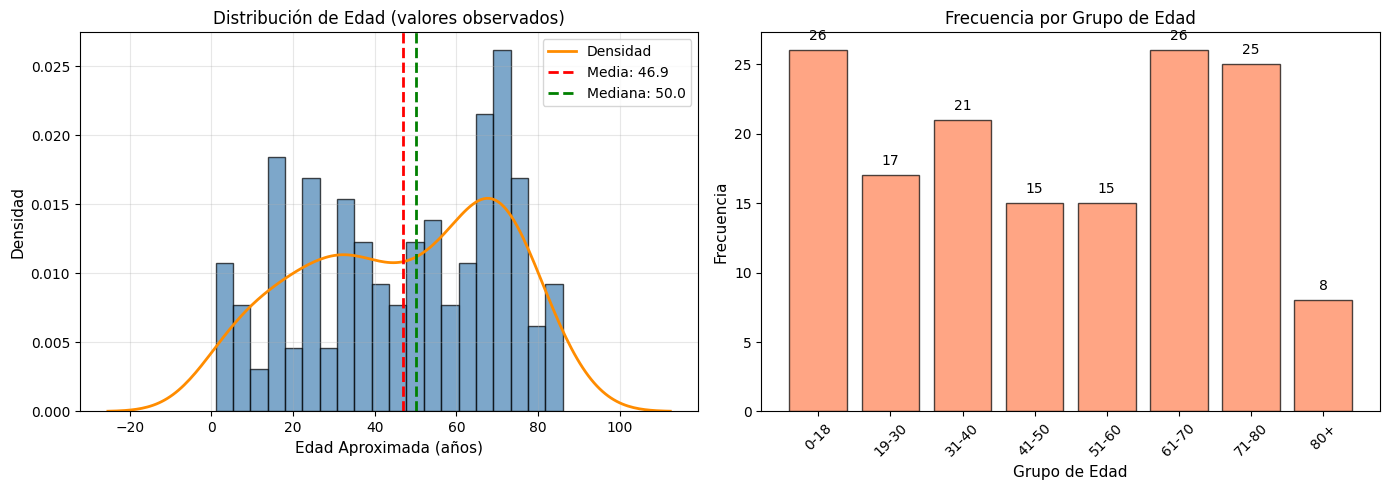


ESTADÍSTICAS DE EDAD APROXIMADA (ANTES DE IMPUTAR)
Total de registros en el dataset: 282
Valores no nulos: 153
Valores nulos: 129
Porcentaje de nulos: 45.7%

📊 Medidas de tendencia central:
   • Media:   46.91 años
   • Mediana: 50.00 años
   • Moda:    71 años

📈 Medidas de dispersión:
   • Desviación estándar: 24.03 años
   • Mínimo: 1 años
   • Máximo: 86 años
   • Rango:  85 años

📐 Medidas de forma:
   • Sesgo (Skewness): -0.251
   • Curtosis: -1.141


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================
# GRÁFICO 1: Histograma con curva de densidad (solo datos no nulos)
# ============================================================
datos_sin_nulos = df['edad_aproximada'].dropna()

# Histograma
axes[0].hist(datos_sin_nulos, bins=20, edgecolor='black', alpha=0.7, color='steelblue', density=True)

# Curva de densidad (KDE)
sns.kdeplot(datos_sin_nulos, ax=axes[0], color='darkorange', linewidth=2, label='Densidad')

# Líneas de media y mediana
axes[0].axvline(datos_sin_nulos.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Media: {datos_sin_nulos.mean():.1f}')
axes[0].axvline(datos_sin_nulos.median(), color='green', linestyle='--', linewidth=2, 
                label=f'Mediana: {datos_sin_nulos.median():.1f}')

# Configurar gráfico 1
axes[0].set_xlabel('Edad Aproximada (años)', fontsize=11)
axes[0].set_ylabel('Densidad', fontsize=11)
axes[0].set_title('Distribución de Edad (valores observados)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# ============================================================
# GRÁFICO 2: Diagrama de barras por grupos de edad
# ============================================================
# Definir grupos de edad
bins_edad = [0, 18, 30, 40, 50, 60, 70, 80, 100]
labels_edad = ['0-18', '19-30', '31-40', '41-50', '51-60', '61-70', '71-80', '80+']

# Crear copia temporal para categorizar (solo para visualización)
df_temp = df.copy()
df_temp['grupo_edad'] = pd.cut(df_temp['edad_aproximada'], bins=bins_edad, labels=labels_edad)

# Contar frecuencias por grupo (excluyendo nulos)
frecuencias = df_temp['grupo_edad'].value_counts().sort_index()

# Graficar barras
bars = axes[1].bar(frecuencias.index, frecuencias.values, edgecolor='black', alpha=0.7, color='coral')

# Configurar gráfico 2
axes[1].set_xlabel('Grupo de Edad', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Frecuencia por Grupo de Edad', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Agregar etiquetas con los valores sobre las barras
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10)

# Ajustar layout
plt.tight_layout()
plt.show()

# ============================================================
# ESTADÍSTICAS DESCRIPTIVAS (ANTES DE IMPUTAR)
# ============================================================
print("\n" + "="*50)
print("ESTADÍSTICAS DE EDAD APROXIMADA (ANTES DE IMPUTAR)")
print("="*50)
print(f"Total de registros en el dataset: {len(df)}")
print(f"Valores no nulos: {df['edad_aproximada'].count()}")
print(f"Valores nulos: {df['edad_aproximada'].isnull().sum()}")
print(f"Porcentaje de nulos: {df['edad_aproximada'].isnull().sum() / len(df) * 100:.1f}%")
print(f"\n📊 Medidas de tendencia central:")
print(f"   • Media:   {datos_sin_nulos.mean():.2f} años")
print(f"   • Mediana: {datos_sin_nulos.median():.2f} años")
print(f"   • Moda:    {datos_sin_nulos.mode().values[0]:.0f} años")
print(f"\n📈 Medidas de dispersión:")
print(f"   • Desviación estándar: {datos_sin_nulos.std():.2f} años")
print(f"   • Mínimo: {datos_sin_nulos.min():.0f} años")
print(f"   • Máximo: {datos_sin_nulos.max():.0f} años")
print(f"   • Rango:  {datos_sin_nulos.max() - datos_sin_nulos.min():.0f} años")
print(f"\n📐 Medidas de forma:")
print(f"   • Sesgo (Skewness): {datos_sin_nulos.skew():.3f}")
print(f"   • Curtosis: {datos_sin_nulos.kurtosis():.3f}")

La variable `edad_aproximada` presenta 129 valores nulos de un total de 282 registros, lo que representa aproximadamente el 45.7% de los datos. Eliminar estos registros implicaría una pérdida significa de información para el modelo, por lo que es necesario aplicar una estrategia de imputación.

La distribución es aproximadamente simétrica:

- La media (46.9 años) y la mediana (50.0 años) son muy cercanas, lo que indica que no hay una asimetría significativa en los datos.

- Los valores extremos (edades muy jóvenes o muy mayores) no son dominantes, como se evidencia en el gráfico de grupos de edad, donde las frecuencias más altas se concentran entre los 41 y 60 años.

No se detectaron outliers significativos:
- El boxplot de la variable no mostró valores atípicos extremos. El rango natural de edad (1-86 años) es consistente con una población general.

La media preserva la inercia estadística global:
- A diferencia de la mediana (que representa el valor central), la media considera todos los valores observados, ponderados por su frecuencia.
- Al imputar con la media, se mantiene la media global de la variable después de la imputación, lo que evita introducir sesgos en la distribución original.

In [17]:
df['edad_aproximada'] = df['edad_aproximada'].fillna(df['edad_aproximada'].median())

In [18]:
df['sector_entidad'] = df['sector_entidad'].str.lower().str.strip()

df['sector_entidad'] = df['sector_entidad'].replace({
    'educativo': 'educacion'
})

In [19]:
df['tipo_entidad'] = df['tipo_entidad'].str.strip()
df['tipo_entidad'] = df['tipo_entidad'].replace({'pública ': 'pública', 'público': 'pública'})

In [20]:
df['representacion'] = df['representacion'].replace({
    'representante_legal': 'representación_legal'
})

In [21]:
X = df.drop(['id_sentencia', 'decision_corte', 'procedencia_tutela'], axis=1)
y = df['procedencia_tutela']

In [22]:
X.duplicated().any()

np.False_

## Análisis exploratorio de variables categóricas

In [23]:
x_categoricas = X.select_dtypes(include=['str'])

In [24]:
x_categoricas.columns

Index(['tema_principal', 'tipo_accionante', 'representacion', 'tipo_entidad',
       'sector_entidad'],
      dtype='str')

In [25]:
print("1. ANÁLISIS DE VARIANZA (FRECUENCIA DE CATEGORÍAS)\n")

for col in x_categoricas:
    freq = df[col].value_counts(normalize=True)
    max_freq = freq.max()
    
    print(f"{col}:")
    print(f"  - Categoría más común: {freq.idxmax()} ({max_freq:.1%})")
    
    if max_freq > 0.95:
        print(f"  ⚠️ RECOMENDACIÓN: EXCLUIR (más del 95% en una categoría)")
    elif max_freq > 0.85:
        print(f"  ⚠️ CONSIDERAR EXCLUIR (más del 85% en una categoría)")
    else:
        print(f"  ✅ OK para incluir")
    print()

1. ANÁLISIS DE VARIANZA (FRECUENCIA DE CATEGORÍAS)

tema_principal:
  - Categoría más común: salud (28.4%)
  ✅ OK para incluir

tipo_accionante:
  - Categoría más común: persona_natural (95.0%)
  ⚠️ RECOMENDACIÓN: EXCLUIR (más del 95% en una categoría)

representacion:
  - Categoría más común: directo (52.5%)
  ✅ OK para incluir

tipo_entidad:
  - Categoría más común: publica (54.6%)
  ✅ OK para incluir

sector_entidad:
  - Categoría más común: otro (34.8%)
  ✅ OK para incluir



In [26]:
from scipy.stats import chi2_contingency

print("2. RELACIÓN CON LA VARIABLE OBJETIVO 'procedencia_tutela'\n")

for col in x_categoricas:
    # Crear tabla de contingencia
    contingency = pd.crosstab(df[col], df['procedencia_tutela'])
    
    # Prueba Chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"{col}:")
    print(f"  - p-valor: {p_value:.4f}")
    
    if p_value > 0.05:
        print(f"  ⚠️ RECOMENDACIÓN: EXCLUIR (no hay relación con procedencia_tutela, p > 0.05)")
    elif p_value > 0.01:
        print(f"  ✅ DÉBIL relación con procedencia_tutela")
    else:
        print(f"  ✅ FUERTE relación con procedencia_tutela (p < 0.01)")
    print()

2. RELACIÓN CON LA VARIABLE OBJETIVO 'procedencia_tutela'

tema_principal:
  - p-valor: 0.3398
  ⚠️ RECOMENDACIÓN: EXCLUIR (no hay relación con procedencia_tutela, p > 0.05)

tipo_accionante:
  - p-valor: 0.0409
  ✅ DÉBIL relación con procedencia_tutela

representacion:
  - p-valor: 0.1197
  ⚠️ RECOMENDACIÓN: EXCLUIR (no hay relación con procedencia_tutela, p > 0.05)

tipo_entidad:
  - p-valor: 0.3322
  ⚠️ RECOMENDACIÓN: EXCLUIR (no hay relación con procedencia_tutela, p > 0.05)

sector_entidad:
  - p-valor: 0.0184
  ✅ DÉBIL relación con procedencia_tutela



In [27]:
print("3. ANÁLISIS DE CARDINALIDAD (NÚMERO DE CATEGORÍAS)\n")

n_registros = len(df)

for col in x_categoricas:
    n_categorias = df[col].nunique()
    proporcion = n_categorias / n_registros
    
    print(f"{col}:")
    print(f"  - Categorías únicas: {n_categorias}")
    print(f"  - Proporción respecto a registros: {proporcion:.2%}")
    
    if n_categorias > 50:
        print(f"  ⚠️ RECOMENDACIÓN: EXCLUIR (demasiadas categorías para {n_registros} registros)")
    elif n_categorias > 20:
        print(f"  ⚠️ CONSIDERAR AGRUPAR categorías o usar Frequency Encoding")
    elif n_categorias == 1:
        print(f"  ⚠️ RECOMENDACIÓN: EXCLUIR (solo una categoría, sin varianza)")
    else:
        print(f"  ✅ OK para incluir")
    print()

3. ANÁLISIS DE CARDINALIDAD (NÚMERO DE CATEGORÍAS)

tema_principal:
  - Categorías únicas: 4
  - Proporción respecto a registros: 1.42%
  ✅ OK para incluir

tipo_accionante:
  - Categorías únicas: 2
  - Proporción respecto a registros: 0.71%
  ✅ OK para incluir

representacion:
  - Categorías únicas: 4
  - Proporción respecto a registros: 1.42%
  ✅ OK para incluir

tipo_entidad:
  - Categorías únicas: 5
  - Proporción respecto a registros: 1.77%
  ✅ OK para incluir

sector_entidad:
  - Categorías únicas: 7
  - Proporción respecto a registros: 2.48%
  ✅ OK para incluir



In [28]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v_robusto(x, y):
    """
    Calcula la V de Cramer de forma robusta manejando casos borde
    """
    # Crear tabla de contingencia
    contingency = pd.crosstab(x, y)
    
    # Si alguna variable tiene menos de 2 categorías, retornar 0
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return 0.0
    
    # Chi-cuadrado
    try:
        chi2, p, dof, expected = chi2_contingency(contingency)
    except:
        return 0.0
    
    n = contingency.sum().sum()
    
    # Calcular V de Cramer
    min_dim = min(contingency.shape) - 1
    
    # Evitar división por cero
    if min_dim == 0 or n == 0:
        return 0.0
    
    cramer_v = np.sqrt(chi2 / (n * min_dim))
    
    # Manejar posibles valores NaN
    if np.isnan(cramer_v) or np.isinf(cramer_v):
        return 0.0
    
    return cramer_v

# Ahora calcular correlaciones de forma segura
print("=== CORRELACIÓN ENTRE VARIABLES CATEGÓRICAS (V de Cramer) ===\n")

from itertools import combinations

categoricas = ['tema_principal', 'tipo_accionante', 'representacion', 
               'tipo_entidad', 'sector_entidad']

for col1, col2 in combinations(categoricas, 2):
    v_cramer = cramers_v_robusto(df[col1], df[col2])
    
    if v_cramer > 0.7:
        print(f"⚠️ ALTA CORRELACIÓN entre '{col1}' y '{col2}': {v_cramer:.3f}")
        print(f"   → Recomendación: excluir una de ellas\n")
    elif v_cramer > 0.5:
        print(f"📊 CORRELACIÓN MODERADA entre '{col1}' y '{col2}': {v_cramer:.3f}\n")
    else:
        print(f"✅ Baja correlación entre '{col1}' y '{col2}': {v_cramer:.3f}")

=== CORRELACIÓN ENTRE VARIABLES CATEGÓRICAS (V de Cramer) ===

✅ Baja correlación entre 'tema_principal' y 'tipo_accionante': 0.245
✅ Baja correlación entre 'tema_principal' y 'representacion': 0.294
✅ Baja correlación entre 'tema_principal' y 'tipo_entidad': 0.324
📊 CORRELACIÓN MODERADA entre 'tema_principal' y 'sector_entidad': 0.577

✅ Baja correlación entre 'tipo_accionante' y 'representacion': 0.354
✅ Baja correlación entre 'tipo_accionante' y 'tipo_entidad': 0.208
✅ Baja correlación entre 'tipo_accionante' y 'sector_entidad': 0.193
✅ Baja correlación entre 'representacion' y 'tipo_entidad': 0.187
✅ Baja correlación entre 'representacion' y 'sector_entidad': 0.289
✅ Baja correlación entre 'tipo_entidad' y 'sector_entidad': 0.375


se van a eliminar:
- `tema_principal`: no explica la variable objetivo y no aporta información útil para predecir
- `representación`: no tiene realación con la variable objetivo
- `tipo_entidad`: no tiene realación con la variable objetivo

In [29]:
categoricas_a_excluir = ['tema_principal', 'representacion', 'tipo_entidad']
X = X.drop(columns=categoricas_a_excluir)

In [30]:
x_categoricas = X.select_dtypes(include=['str'])
x_categoricas.columns

Index(['tipo_accionante', 'sector_entidad'], dtype='str')

In [31]:
for i in x_categoricas:
    print(i)
    print(X[i].unique())
    print()

tipo_accionante
<StringArray>
['persona_natural', 'persona_juridica']
Length: 2, dtype: str

sector_entidad
<StringArray>
[          'salud',            'otro',       'pensiones',       'educacion',
        'judicial',  'administrativo', 'no especificado']
Length: 7, dtype: str



procesamiento recomendado para:
- `tipo_accionante`: binary encoding simple
- `sector_entidad`: one-hot encoding

## Análisis exploratorio de varialbes numéricas

In [32]:
variables_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [33]:
variables_numericas

['año',
 'sujeto_especial_proteccion',
 'edad_aproximada',
 'derecho_salud',
 'minimo_vital',
 'debido_proceso',
 'seguridad_social',
 'igualdad',
 'existe_otro_medio_defensa',
 'medio_es_idoneo',
 'se_alega_perjuicio_irremediable',
 'perjuicio_irremediable_probado',
 'subsidiariedad_cumplida',
 'legitimacion_activa',
 'legitimacion_pasiva',
 'urgencia',
 'afecta_minimo vital',
 'afecta_salud',
 'caso_involucra_servicio_publico',
 'dias_desde_hecho',
 'hay_inmediatez']

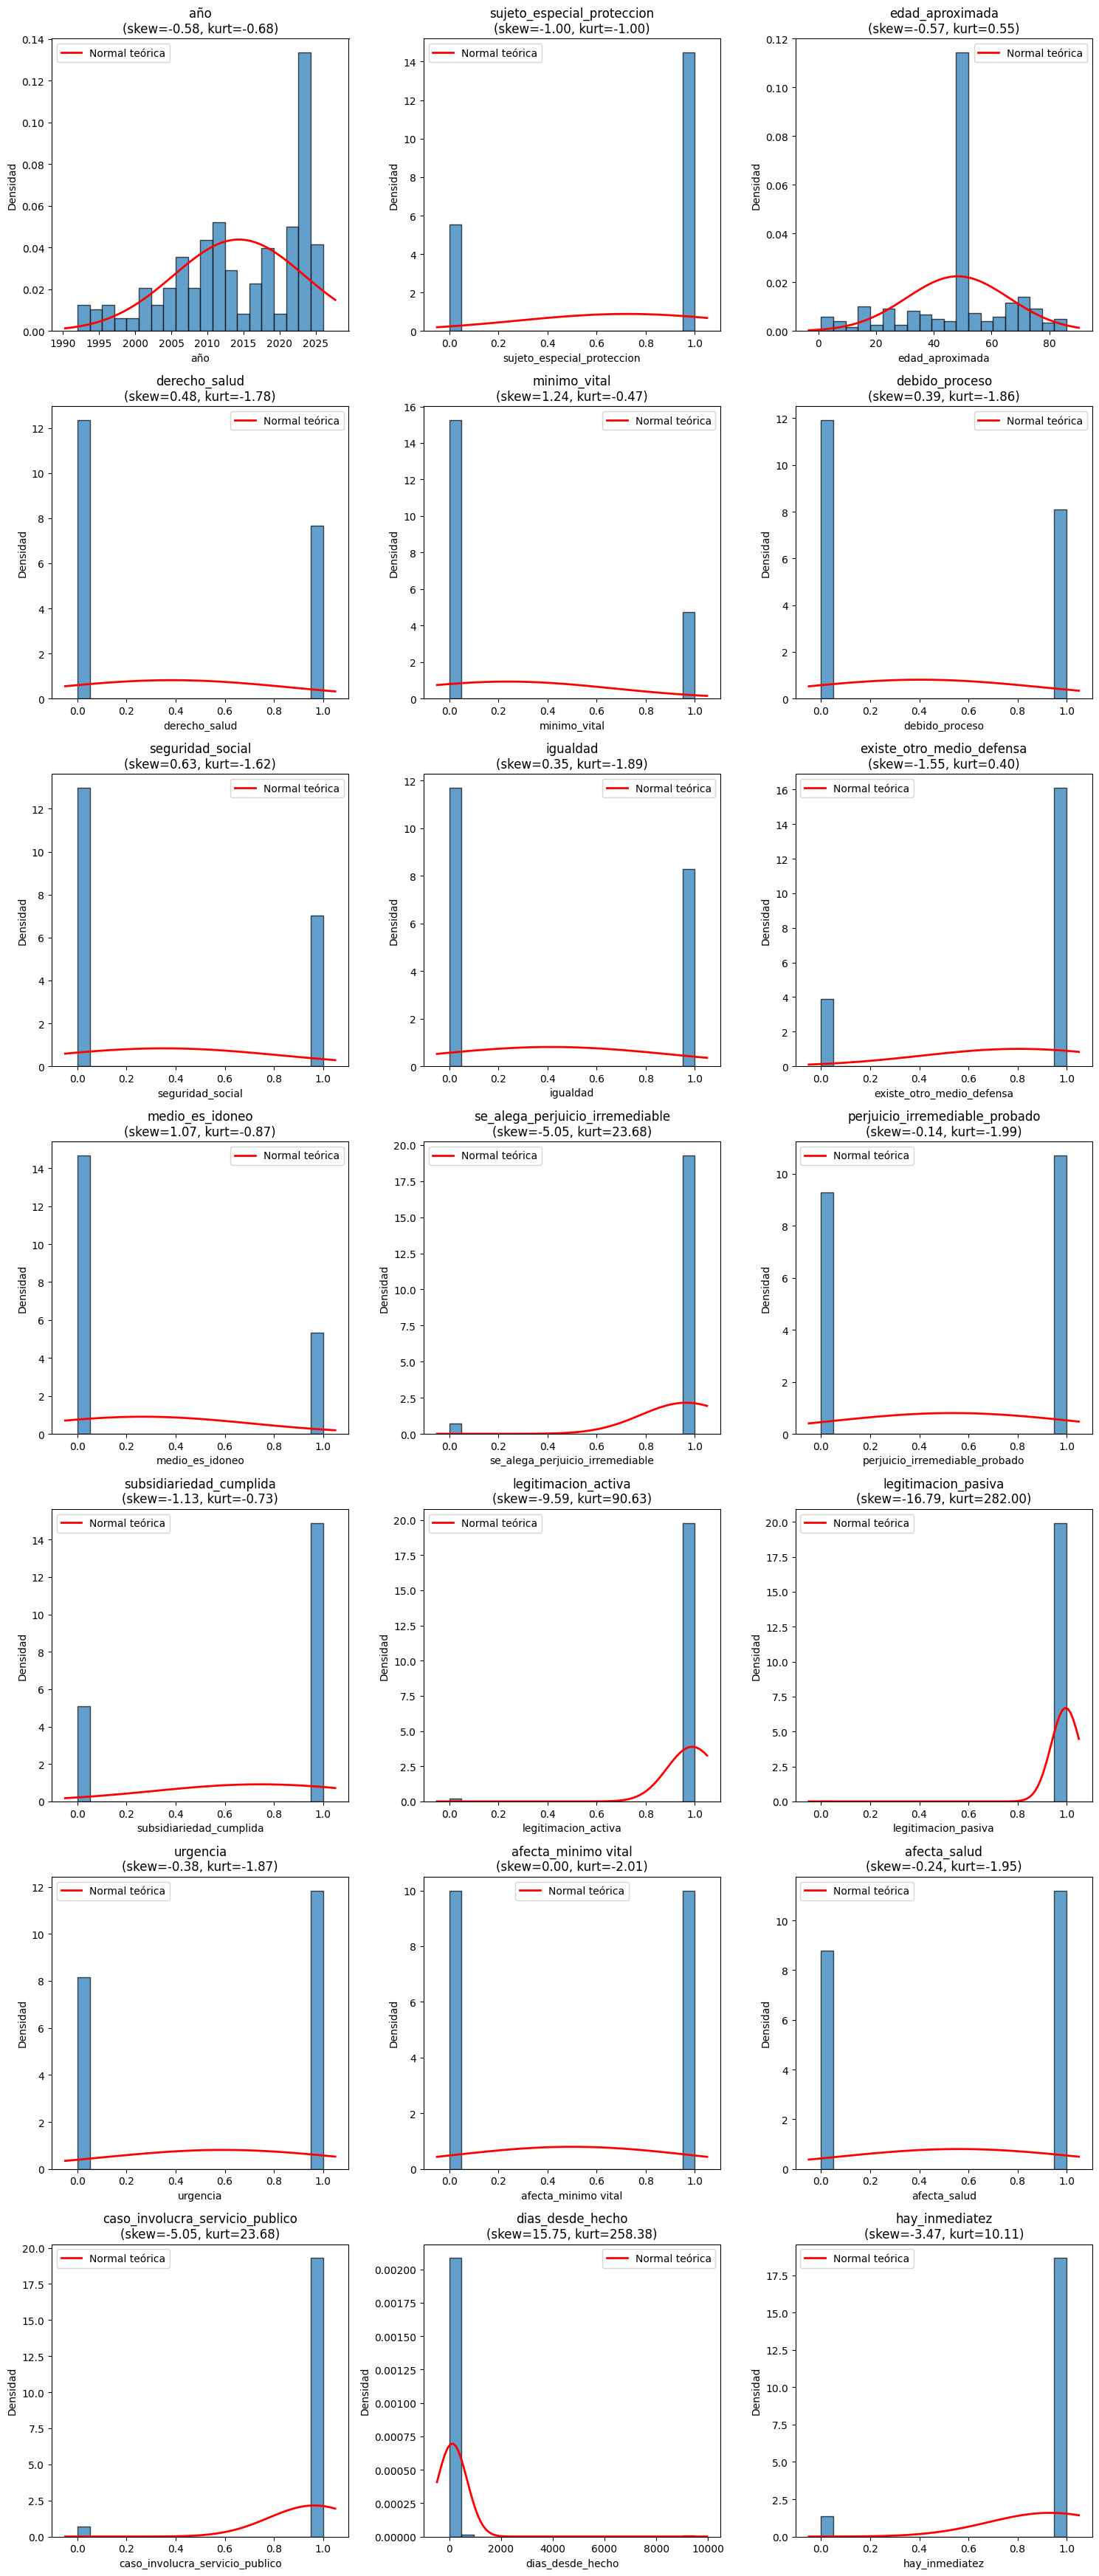

In [34]:
# Configurar subplots
n_vars = len(variables_numericas)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_vars > 1 else [axes]

for i, var in enumerate(variables_numericas):
    # Histograma
    axes[i].hist(X[var].dropna(), bins=20, density=True, alpha=0.7, edgecolor='black')
    
    # Curva de densidad normal teórica
    mu, std = X[var].mean(), X[var].std()
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    axes[i].plot(x, p, 'r-', linewidth=2, label='Normal teórica')
    
    axes[i].set_title(f'{var}\n(skew={X[var].skew():.2f}, kurt={X[var].kurtosis():.2f})')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Densidad')
    axes[i].legend()

# Ocultar ejes no usados
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [35]:
binarias = [var for var in variables_numericas if X[var].nunique() <= 2]
continuas = [var for var in variables_numericas if X[var].nunique() > 2]

print("=== VARIABLES NUMÉRICAS ===")
print(f"Binarias (0/1): {len(binarias)}")
print(f"Continuas: {len(continuas)}")
print(f"\nVariables continuas a analizar: {continuas}")

=== VARIABLES NUMÉRICAS ===
Binarias (0/1): 18
Continuas: 3

Variables continuas a analizar: ['año', 'edad_aproximada', 'dias_desde_hecho']


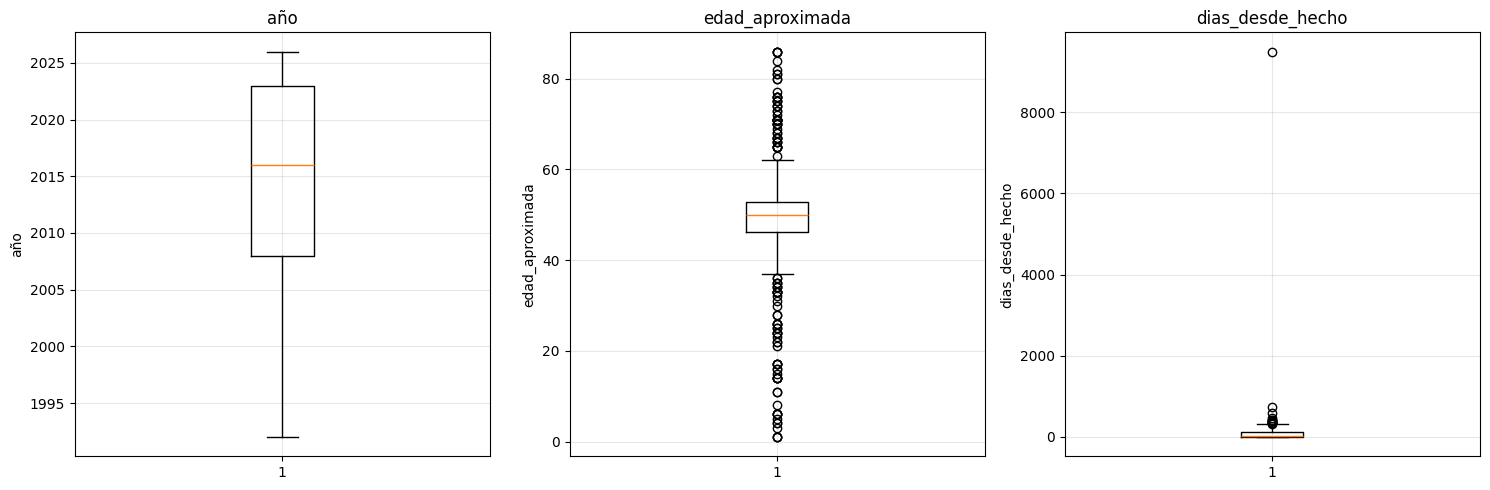

In [36]:

if continuas:
    n_vars = len(continuas)
    fig, axes = plt.subplots(1, n_vars, figsize=(5*n_vars, 5))
    
    if n_vars == 1:
        axes = [axes]
    
    for i, var in enumerate(continuas):
        axes[i].boxplot(X[var].dropna())
        axes[i].set_title(f'{var}')
        axes[i].set_ylabel(var)
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay variables continuas para analizar")

## Procesamiento de las variables numéricas: `edad_aproximada` y `dias_desde_hecho`

Dentro del conjunto de datos, dos variables numéricas requirieron un análisis especial debido a sus características particulares: `edad_aproximada` y `dias_desde_hecho`. Ambas presentaban valores faltantes codificados como `-1`, pero su comportamiento estadístico era muy diferente, por lo que se les aplicaron estrategias de procesamiento distintas.

### Variable `dias_desde_hecho`

Esta variable mide el tiempo transcurrido entre el hecho que motivó la tutela y la emisión de la sentencia. En el análisis exploratorio se observó que su distribución era fuertemente asimétrica hacia la derecha, con una cola muy larga de valores extremadamente altos (hasta 9490 días). Además, presentaba múltiples valores atípicos y una cantidad considerable de datos faltantes.

Para corregir esta asimetría, se aplicó una transformación logarítmica mediante `np.log1p`, que ayuda a normalizar la distribución y a reducir el impacto de los valores extremos. Posteriormente, los valores nulos (que originalmente estaban codificados como `-1`) fueron reemplazados por la media del resto de los datos. Finalmente, la variable se estandarizó con `StandardScaler` para centrarla y escalarla, lo que facilita el trabajo de los modelos basados en gradiente y mejora la interpretación de los coeficientes.

### Variable `edad_aproximada`

Esta variable representa la edad del accionante. A diferencia de la anterior, su distribución resultó ser aproximadamente normal, con una media de 46.9 años y una mediana de 50 años, valores muy cercanos entre sí. No se detectaron outliers significativos. Sin embargo, presentó una tasa de valores nulos muy alta, cercana al 46% de los registros, lo que hacía inviable simplemente eliminar esas filas.

Dado que la distribución es prácticamente simétrica y no hay valores extremos, se optó por un tratamiento más conservador. Los valores faltantes se imputaron utilizando la **mediana** (50 años), en lugar de la media. La mediana es ligeramente más robusta ante la leve asimetría positiva que presenta la variable y, al estar menos influenciada por valores atípicos menores, representa mejor el punto central de los datos. A diferencia de `dias_desde_hecho`, no se aplicó ninguna transformación logarítmica ni estandarización, ya que la regresión logística utilizada como modelo no es sensible a la escala de las variables.

In [37]:
from sklearn.model_selection import train_test_split


In [38]:
print("=== VERIFICACIÓN PREVIA ===")
print(f"Tamaño de X: {X.shape}")
print(f"Tamaño de y: {len(y)}")
print(f"Distribución de y:\n{y.value_counts(normalize=True).round(4)}")

=== VERIFICACIÓN PREVIA ===
Tamaño de X: (282, 23)
Tamaño de y: 282
Distribución de y:
procedencia_tutela
1    0.7624
0    0.2376
Name: proportion, dtype: float64


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,          
    random_state=42,          
    stratify=y             
)

In [40]:
print("\n=== TAMAÑOS DE LOS CONJUNTOS ===")
print(f"X_train: {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)")
print(f"X_test:  {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)")
print(f"y_train: {len(y_train)} registros")
print(f"y_test:  {len(y_test)} registros")


=== TAMAÑOS DE LOS CONJUNTOS ===
X_train: (211, 23) (74.8%)
X_test:  (71, 23) (25.2%)
y_train: 211 registros
y_test:  71 registros


transformada logaritmica para `dias_desde_hecho`

In [41]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Columnas
binary_col = ['tipo_accionante']
onehot_col = ['sector_entidad']
num_col_log = ['dias_desde_hecho']      # necesita transformación logarítmica
num_col_normal = ['edad_aproximada']    # distribución normal, solo imputación

# ---- Función: reemplazar -1 por NaN ---- #
def replace_minus_one(X):
    X = np.array(X, dtype=float)
    X[X == -1] = np.nan
    return X

# ---- Pipeline para variables con asimetría (requieren log) ---- #
num_pipeline_log = Pipeline(steps=[
    ('replace_-1', FunctionTransformer(replace_minus_one, 
                                       validate=False, 
                                       feature_names_out='one-to-one')),
    ('imputer', SimpleImputer(strategy='mean')),      # media para días
    ('log', FunctionTransformer(np.log1p, 
                                validate=False, 
                                feature_names_out='one-to-one')), 
    ('scaler', StandardScaler())
])

# ---- Pipeline para variables con distribución normal (edad) ---- #
num_pipeline_normal = Pipeline(steps=[
    ('replace_-1', FunctionTransformer(replace_minus_one, 
                                       validate=False, 
                                       feature_names_out='one-to-one')),
    ('imputer', SimpleImputer(strategy='median'))      # mediana para edad
    # NOTA: No se aplica log ni scaler porque no es necesario
])

# ---- Categóricas ---- #
onehot_pipeline = OneHotEncoder(handle_unknown='ignore')
binary_pipeline = OneHotEncoder(drop='if_binary', handle_unknown='ignore')

# ---- ColumnTransformer ---- #
preprocessor = ColumnTransformer(
    transformers=[
        ('num_log', num_pipeline_log, num_col_log),
        ('num_normal', num_pipeline_normal, num_col_normal),
        ('cat_onehot', onehot_pipeline, onehot_col),
        ('cat_binary', binary_pipeline, binary_col)
    ],
    remainder='passthrough'
)

se utilizó la media y no la imputación por -1 (como anteriormente se realizó) debido a que la transformación a log1p el valor -1 no es permitido, además en eeste caso la media no cambia la distribución

In [42]:
X_train_processed = preprocessor.fit_transform(X_train)

In [43]:
X_test_processed = preprocessor.transform(X_test)

In [44]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [45]:
rf_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [46]:
from sklearn.metrics import accuracy_score
y_pred_train = rf_model.predict(X_train_processed)
y_pred_test = rf_model.predict(X_test_processed)

train_score = accuracy_score(y_train, y_pred_train)
test_score = accuracy_score(y_test, y_pred_test)

print("=== REPORTE DE PERFORMANCE ===")
print(f"Score Entrenamiento (Accuracy): {train_score:.4f}")
print(f"Score Prueba (Accuracy):        {test_score:.4f}")
print("-" * 30)

=== REPORTE DE PERFORMANCE ===
Score Entrenamiento (Accuracy): 1.0000
Score Prueba (Accuracy):        0.9014
------------------------------


In [47]:

feature_names = preprocessor.get_feature_names_out()

print(f"\n=== LISTADO DE CARACTERÍSTICAS ({len(feature_names)}) ===")
for i, name in enumerate(feature_names):
    # Limpiamos un poco el prefijo que pone Scikit-learn (opcional)
    clean_name = name.replace('cat__', '').replace('num__', '')
    print(f"{i+1}. {clean_name}")


=== LISTADO DE CARACTERÍSTICAS (29) ===
1. num_log__dias_desde_hecho
2. num_normal__edad_aproximada
3. cat_onehot__sector_entidad_administrativo
4. cat_onehot__sector_entidad_educacion
5. cat_onehot__sector_entidad_judicial
6. cat_onehot__sector_entidad_no especificado
7. cat_onehot__sector_entidad_otro
8. cat_onehot__sector_entidad_pensiones
9. cat_onehot__sector_entidad_salud
10. cat_binary__tipo_accionante_persona_natural
11. remainder__año
12. remainder__sujeto_especial_proteccion
13. remainder__derecho_salud
14. remainder__minimo_vital
15. remainder__debido_proceso
16. remainder__seguridad_social
17. remainder__igualdad
18. remainder__existe_otro_medio_defensa
19. remainder__medio_es_idoneo
20. remainder__se_alega_perjuicio_irremediable
21. remainder__perjuicio_irremediable_probado
22. remainder__subsidiariedad_cumplida
23. remainder__legitimacion_activa
24. remainder__legitimacion_pasiva
25. remainder__urgencia
26. remainder__afecta_minimo vital
27. remainder__afecta_salud
28. r

## Entrega 3
> la segunda entrega se ha vuelto hacer debido a que los estudiantes de derecho encargados de generar el conjunto de datos han agregado datos nuevos

### Punto 1
Preparación de datos: separar el conjunto en entrenamiento y prueba, y aplicar transformaciones necesarias para las características numéricas y categóricas de manera independiente.

Este código ya está en el notebook. El `preprocessor` con `ColumnTransformer` y el `train_test_split` con `stratify=y` cubren este punto

### Punto 2
Implementación de un modelo lineal regularizado adecuado al tipo de variable que se pretende predecir.

El pipeline completo con todos los pasos de preprocesamiento,
selección de características y el clasificador se define en el
Punto 3, donde también se realiza la sintonización de hiperparámetros
para evitar data leakage.

### Punto 3
Sintonización de hiperparámetros mediante validación cruzada, utilizando una técnica distinta de GridSearchCV.

Se utiliza `RandomizedSearchCV`, que a diferencia de `GridSearchCV` no prueba exhaustivamente todas las combinaciones posibles sino que muestrea aleatoriamente el espacio de búsqueda. Esto es más eficiente cuando el espacio de hiperparámetros es grande, permitiendo explorar rangos continuos (como `C`) con distribuciones de probabilidad.

Los hiperparámetros a sintonizar son:
- `C`: controla la fuerza de regularización (valores pequeños = más regularización). Se muestrea con distribución log-uniforme para explorar varios órdenes de magnitud
- `l1_ratio`: define el tipo de regularización. 0.0 equivale a Ridge (L2), 1.0 a Lasso (L1), y 0.5 a ElasticNet (combinación de ambas)
- `selector__k`: número de características a seleccionar con `SelectKBest`, lo que permite reducir dimensionalidad dentro del pipeline

Se emplea `StratifiedKFold` con 5 folds para garantizar que la proporción de clases se mantenga en cada partición, lo cual es importante dado el desbalance entre clases.

La métrica de optimización es `f1_weighted`, consistente con el problema de clasificación desbalanceada, ya que pondera el F1 de cada clase por su frecuencia.

In [48]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from scipy.stats import loguniform
import warnings
from sklearn.exceptions import ConvergenceWarning

logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)),
    ('variance_filter', VarianceThreshold(threshold=0.0)),  # elimina columnas constantes
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression(
        solver='saga',
        max_iter=5000,
        random_state=42,
        class_weight='balanced'
    ))
])

param_distributions = {
    'classifier__C': loguniform(1e-4, 1e2),
    'classifier__l1_ratio': [0.0, 0.5, 1.0],
    'selector__k': [5, 8, 10, 'all'],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='f1_weighted',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    random_search.fit(X_train, y_train)

print("=== MEJORES HIPERPARÁMETROS ===")
print(random_search.best_params_)
print(f"\nMejor F1 (CV): {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
=== MEJORES HIPERPARÁMETROS ===
{'classifier__C': np.float64(0.00022310108018679258), 'classifier__l1_ratio': 0.0, 'selector__k': 'all'}

Mejor F1 (CV): 0.8455


### Punto 4
Reporte e interpretación de métricas de desempeño relevantes: las métricas empleadas para evaluar el modelo y ajustar los hiperparámetros deben ser consistentes con el problema del proyecto. Deben reportarse los resultados de la validación cruzada, así como las métricas de entrenamiento y de prueba

=== MÉTRICAS DE ENTRENAMIENTO ===
Accuracy:     0.8389
F1 Weighted:  0.8464

=== MÉTRICAS DE PRUEBA ===
Accuracy:     0.8873
F1 Weighted:  0.8925
AUC-ROC:      0.9368

=== REPORTE DE CLASIFICACIÓN (PRUEBA) ===
              precision    recall  f1-score   support

           0       0.70      0.94      0.80        17
           1       0.98      0.87      0.92        54

    accuracy                           0.89        71
   macro avg       0.84      0.91      0.86        71
weighted avg       0.91      0.89      0.89        71


=== TOP 5 COMBINACIONES (VALIDACIÓN CRUZADA) ===
 param_classifier__C  param_classifier__l1_ratio  mean_test_score  std_test_score  mean_train_score
            0.000223                         0.0         0.845482        0.037320          0.850600
            0.000540                         0.0         0.845482        0.037320          0.851790
            0.001653                         0.0         0.841180        0.033843          0.854066
            0

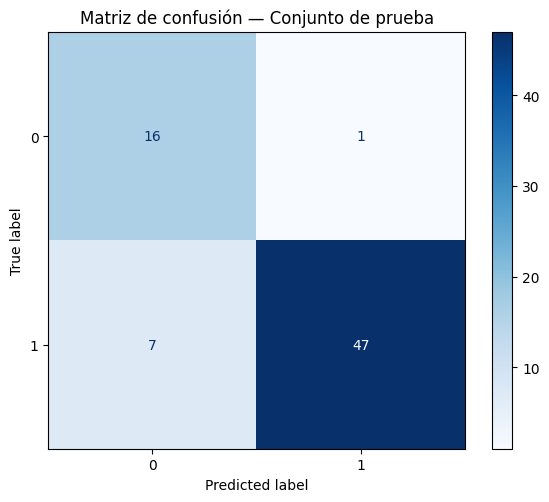

In [49]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

best_model = random_search.best_estimator_

# Predicciones
y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

# --- Métricas globales ---
print("=== MÉTRICAS DE ENTRENAMIENTO ===")
print(f"Accuracy:     {accuracy_score(y_train, y_pred_train):.4f}")
print(f"F1 Weighted:  {f1_score(y_train, y_pred_train, average='weighted'):.4f}")

print("\n=== MÉTRICAS DE PRUEBA ===")
print(f"Accuracy:     {accuracy_score(y_test, y_pred_test):.4f}")
print(f"F1 Weighted:  {f1_score(y_test, y_pred_test, average='weighted'):.4f}")

# AUC-ROC (si la variable objetivo es binaria)
if len(y.unique()) == 2:
    y_prob = best_model.predict_proba(X_test)[:, 1]
    print(f"AUC-ROC:      {roc_auc_score(y_test, y_prob):.4f}")

# --- Reporte detallado ---
print("\n=== REPORTE DE CLASIFICACIÓN (PRUEBA) ===")
print(classification_report(y_test, y_pred_test))

# --- Resultados de validación cruzada ---
cv_results = pd.DataFrame(random_search.cv_results_)
top5 = cv_results.sort_values('mean_test_score', ascending=False).head(5)

print("\n=== TOP 5 COMBINACIONES (VALIDACIÓN CRUZADA) ===")
print(top5[['param_classifier__C', 'param_classifier__l1_ratio',
            'mean_test_score', 'std_test_score',
            'mean_train_score']].to_string(index=False))

# --- Matriz de confusión ---
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=ax, cmap='Blues')
ax.set_title('Matriz de confusión — Conjunto de prueba')
plt.tight_layout()
plt.show()

### Punto 5
Presentación e interpretación de los coeficientes del modelo.

=== TOP 15 CARACTERÍSTICAS MÁS INFLUYENTES ===
                 característica  coeficiente  abs_coeficiente
        subsidiariedad_cumplida     0.015910         0.015910
                       urgencia     0.015491         0.015491
                medio_es_idoneo    -0.013954         0.013954
 perjuicio_irremediable_probado     0.013187         0.013187
     sujeto_especial_proteccion     0.009668         0.009668
            afecta_minimo vital     0.008845         0.008845
                 hay_inmediatez     0.007026         0.007026
                   afecta_salud     0.006641         0.006641
       sector_entidad_educacion     0.004516         0.004516
            legitimacion_activa     0.004275         0.004275
      existe_otro_medio_defensa    -0.004010         0.004010
        sector_entidad_judicial    -0.003283         0.003283
            sector_entidad_otro    -0.002623         0.002623
tipo_accionante_persona_natural     0.002513         0.002513
se_alega_perjuicio_irre

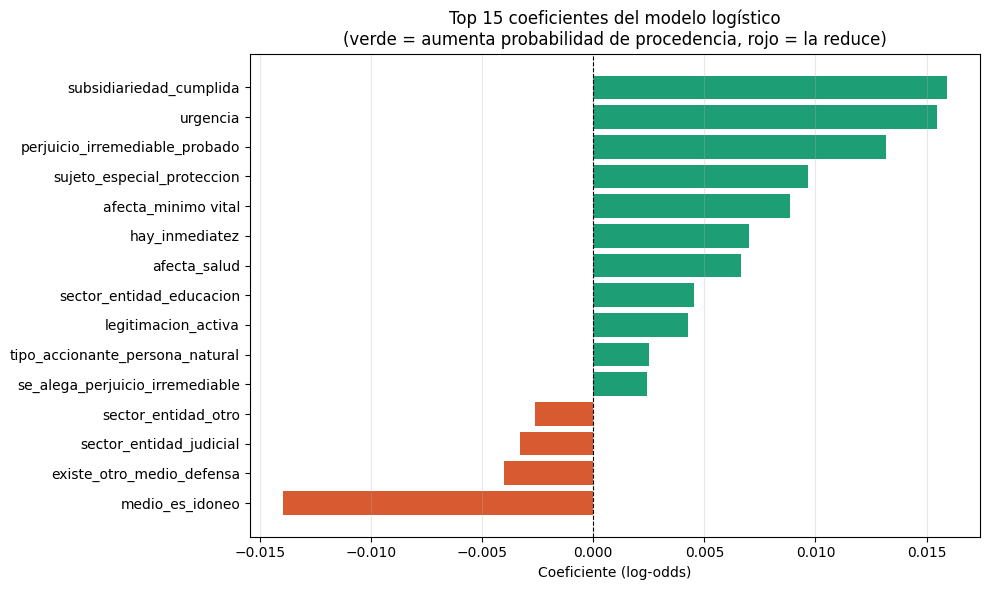


=== INTERPRETACIÓN ===
Los coeficientes representan el cambio en log-odds de 'procedencia_tutela'.
Un coeficiente positivo indica que la característica aumenta la probabilidad de que la tutela proceda.
Un coeficiente negativo indica lo contrario.

Factor con mayor efecto POSITIVO: subsidiariedad_cumplida
Factor con mayor efecto NEGATIVO: medio_es_idoneo


In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extraer pasos del pipeline
preprocessor_fitted = best_model.named_steps['preprocessor']
variance_filter = best_model.named_steps['variance_filter']
selector = best_model.named_steps['selector']
classifier = best_model.named_steps['classifier']

# Nombres tras el preprocesador
feature_names_raw = preprocessor_fitted.get_feature_names_out()

# Aplicar máscara del VarianceThreshold
feature_names_var = feature_names_raw[variance_filter.get_support()]

# Aplicar máscara del SelectKBest
feature_names_final = feature_names_var[selector.get_support()]

# Limpiar prefijos
feature_names_clean = [
    name.replace('num__', '').replace('cat_onehot__', '')
        .replace('cat_binary__', '').replace('remainder__', '')
    for name in feature_names_final
]

# Coeficientes
coefs = classifier.coef_[0]

coef_df = pd.DataFrame({
    'característica': feature_names_clean,
    'coeficiente': coefs,
    'abs_coeficiente': np.abs(coefs)
}).sort_values('abs_coeficiente', ascending=False)

print("=== TOP 15 CARACTERÍSTICAS MÁS INFLUYENTES ===")
print(coef_df.head(15).to_string(index=False))

# --- Gráfico ---
top_n = min(15, len(coef_df))
top_coef = coef_df.head(top_n).sort_values('coeficiente')

colors = ['#D85A30' if c < 0 else '#1D9E75' for c in top_coef['coeficiente']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_coef['característica'], top_coef['coeficiente'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coeficiente (log-odds)')
ax.set_title(f'Top {top_n} coeficientes del modelo logístico\n'
             f'(verde = aumenta probabilidad de procedencia, rojo = la reduce)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Interpretación ---
print("\n=== INTERPRETACIÓN ===")
print("Los coeficientes representan el cambio en log-odds de 'procedencia_tutela'.")
print("Un coeficiente positivo indica que la característica aumenta la probabilidad de que la tutela proceda.")
print("Un coeficiente negativo indica lo contrario.\n")
print(f"Factor con mayor efecto POSITIVO: {coef_df.loc[coef_df['coeficiente'].idxmax(), 'característica']}")
print(f"Factor con mayor efecto NEGATIVO: {coef_df.loc[coef_df['coeficiente'].idxmin(), 'característica']}")